In [7]:
import os
import load_dotenv
from load_dotenv import load_dotenv

# This function will load all the variable from the .env file and 
# make them available in the os.environ dictionary (env variables)
load_dotenv()

if os.environ.get("CLAUDE_API_KEY"):
    print("CLAUDE API KEY has been loaded")
else:
    raise ValueError("CLAUDE API KEY not found")

if os.environ.get("TAVILY_API_KEY"):
    print("TAVILY API KEY has been loaded")
else:
    raise ValueError("TAVILY API KEY not found")

CLAUDE API KEY has been loaded
TAVILY API KEY has been loaded


In [8]:
from langchain_anthropic import ChatAnthropic

llm_anthropic = ChatAnthropic(
    model = os.environ.get("CLAUDE_MODEL"),
    api_key = os.environ.get('CLAUDE_API_KEY'),
    temperature = 0,
    base_url = os.environ.get("CLAUDE_BASE_URL")
)
llm_anthropic

ChatAnthropic(metadata={'lc_versions': {'langchain-core': '1.5.4', 'langchain': '1.3.15', 'langchain-anthropic': '1.5.5'}}, model='vertex_ai.anthropic.claude-opus-4-6', max_tokens=4096, temperature=0.0, anthropic_api_url='https://genai-sharedservice-americas.pwcinternal.com', anthropic_api_key=SecretStr('**********'), model_kwargs={})

In [1]:
# TOOL - 1 [Tavily Search Tool]

from langchain_tavily import TavilySearch
from langchain.tools import tool

@tool
def tavily_tool(query: str) -> str:

    """This tool searches the latest news on Tavily for the given query and returns the results."""

    tavily_tool = TavilySearch(
        api_key = os.environ.get('TAVILY_API_KEY'),
        max_results = 5,
        description = "This is a tavily tool to search the web for current information"
    )

    tavily_tool.invoke("Today's Trending News about Langchain !!")
    
    return tavily_tool.invoke(query)

In [2]:
# TOOL - 2 [Arxiv Query Search Tool]

from langchain_community.tools import ArxivQueryRun, tool
from langchain_community.utilities import ArxivAPIWrapper

@tool
def arxiv_tool(query: str) -> str:

    """ This tool allows you to query the Arxiv database for research papers. """
    arxiv_query = ArxivQueryRun(api_wrapper=ArxivAPIWrapper())
    
    return arxiv_query.invoke(query)

/var/folders/4v/c1sk_74d58qfls46gv355_5h0000gn/T/ipykernel_12712/585825190.py:3: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import ArxivQueryRun, tool


In [3]:
# TOOL - 3 [Wikipedia Search Tool]

from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

@tool
def wiki_tool(query: str):

    """This tool allows you to search Wikipedia for information on a given topic. """

    wiki_query = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())
    return wiki_query.invoke(query)

In [4]:
# TOOL 4 - Custom Tool

from langchain.tools import tool

@tool # This decorator automatically converts this function internally into a tool
def personal_info(name: str):

    """ Use this tool to get personal information about Sayani, Alice and Charlie. """
    info = {
        "Sayani": "Sayani is a data scientist currently focusing on building LLM and RAG pipelines.",
        "Alice": "Alice is a data engineer with 4 years of experience",
        "Charlie": "Charlie is a product manager with a background in tech startups."
    }
    return info.get(name, "No information available for this person")

In [5]:
personal_info.invoke("Sayani")

'Sayani is a data scientist currently focusing on building LLM and RAG pipelines.'

#### TOOL Binding

In [ ]:
tools = [tavily_tool, arxiv_tool, wiki_tool, personal_info]

llm_with_tools = llm_anthropic.bind_tools(tools)

response = llm_with_tools.invoke("What is the latest news on AI?")
response.tool_calls

#### LangGraph Creation

#### Schema Creation

In [10]:
from typing import TypedDict, List 

class graph_schema(TypedDict):
    messages: List

#### Create Node Functions

In [11]:
from langchain_core.prompts import ChatPromptTemplate

def llm_node(state: graph_schema) -> graph_schema:

    messages = state['messages']

    # Prompt template for the LLM, including system instructions and the human input
    prompt = ChatPromptTemplate.from_messages(
        [
            ("system", "You are a helpful assistant than can use tools to answer questions"),
            ("human", "{input}")
        ]
    )

    # LLM with Tools
    chain = prompt | llm_with_tools
    response = chain.invoke({"input": messages})

    # Update the state with the new message
    state['messages'] = messages + [response]

    return state

In [12]:
from langchain_core.messages import HumanMessage, ToolMessage
def tool_node(state: graph_schema) -> graph_schema:

    messages = state['messages']

    tools_by_name = {tool.name: tool for tool in tools}

    tool_results = []

    for tool_call in messages[-1].tool_calls:

        tool = tools_by_name.get(tool_call["name"])

        observation = tool.invoke(tool_call["args"])

        tool_results.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))

    # Update the state with the tool results
    state['messages'] = messages + tool_results

#### Create Conditional Edge Function

In [14]:
def if_tool_call(state: graph_schema) -> str:

    last_message = state['messages'][-1]

    if last_message.tool_calls:
        return "tool_node"
    else:
        return "end"

#### Create State Graph

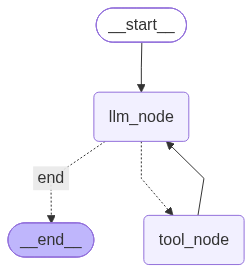

In [15]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

graph = StateGraph(graph_schema)

# Adding nodes to the graph
graph.add_node("llm_node", llm_node)
graph.add_node("tool_node", tool_node)

# Adding Edges between the nodes
graph.add_edge(START, "llm_node")
graph.add_conditional_edges("llm_node", if_tool_call, {"tool_node": "tool_node", "end": END})
graph.add_edge("tool_node", "llm_node")
graph.add_edge("llm_node", END)

react_graph = graph.compile()

Image(react_graph.get_graph().draw_mermaid_png())

#### Graph Invocation

In [ ]:
react_graph.invoke(({"messages": [HumanMessage(content = "What is the latest news on AI ?")]}))

In [ ]:
for chunk in react_graph.stream(
    {"messages" : [HumanMessage(content = "What is the latest news on AI ?")]},
    stream_mode = "updates"
):
    print(chunk)